# Comparison of deconvolver calibrators

In this notebook, we compare the performance of the our linear calibrator
versus temperature scaling, vector scaling and dirichlet calibration.

## Imports and utility functions

In [32]:
import os
from pathlib import Path
import json
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.model_selection import KFold, ParameterGrid
from scipy.stats import linregress

from EDA.edautils import plot_deconvolution_results
from methyldl.deconvolution.evaluation import compute_deconvolution_metrics
from methyldl.deconvolution.linear_calibrator import LinearCalibrator
from EDA.dirichlet_calibration import DirichletCalibrator

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def prod_len_dict_keys(dict_: dict) -> int:
    return reduce(lambda x, y: x * y, list(map(len, dict_.values())), 1)

In [3]:
def plot_mixtures_pred_vs_true(
    ground_truth_mixture: np.ndarray,
    predicted_mixtures: list[np.ndarray],
    predicted_mixture_labels: list[str],
    width: float = 0.2,
    title: str = "Predicted Mixtures vs Ground Truth Mixture",
    ctype_names: list[str] = None,
):
    """
    Plot the predicted mixtures against the ground truth mixture for a single sample.
    The function creates a bar plot where the x axis represents the cell types and the y axis represents the mixture proportions.
    Each predicted mixture is plotted as a separate bar. The ground truth mixture is plotted as red dots for each cell type.

    Args:
        ground_truth_mixture: A 1D array of shape (n_cell_types,) representing the true mixture proportions.
        predicted_mixtures: A list of 1D arrays, each of shape (n_cell_types,), representing the predicted mixture proportions from different models.
        predicted_mixture_labels: A list of strings representing the labels for each predicted mixture (e.g., model names).
    """
    assert len(predicted_mixtures) == len(
        predicted_mixture_labels
    ), "Number of predicted mixtures must match number of labels"
    assert all(
        pred.shape == ground_truth_mixture.shape for pred in predicted_mixtures
    ), "All predicted mixtures must have the same shape as the ground truth mixture"
    plt.figure(figsize=(8, 6))
    n_cell_types = len(ground_truth_mixture)
    n_predicted_mixtures = len(predicted_mixtures)
    x = np.arange(n_cell_types)  # start of the the label locations
    x_center = (
        x + width * (n_predicted_mixtures - 1) / 2
    )  # middle of the group of bars for each cell type

    # Plot the ground truth mixture as red dots
    plt.scatter(
        x_center, ground_truth_mixture, color="red", zorder=-1, label="Ground Truth"
    )

    # Plot each predicted mixture as a bar
    for i, (predicted_mixture, label) in enumerate(
        zip(predicted_mixtures, predicted_mixture_labels)
    ):
        plt.bar(x + i * width, predicted_mixture, width, label=label, alpha=0.7)

    # plot the cell types names on the x axis, rotated by 90 degrees
    if ctype_names is not None:
        plt.xticks(x_center, ctype_names, rotation=90)
    plt.ylabel("Mixture Proportions")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

In [4]:
def plot_heatmap(
    matrix: np.ndarray,
    title: str = "Heatmap",
    color_bar_label: str = "Probability",
    xlabel="Predicted Class",
    ylabel="True Class",
    x_ticks: list[str] = None,
    y_ticks: list[str] = None,
    vmin: float | None = None,
    vmax: float | None = None,
):
    """Plot a heatmap of the given matrix with cell type names on the axes."""
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(label=color_bar_label)
    plt.xticks(
        ticks=np.arange(matrix.shape[1]),
        labels=(
            x_ticks if x_ticks is not None else [str(i) for i in range(matrix.shape[1])]
        ),
        rotation=90,
    )
    plt.yticks(
        ticks=np.arange(matrix.shape[0]),
        labels=(
            y_ticks if y_ticks is not None else [str(i) for i in range(matrix.shape[0])]
        ),
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

## Data loading

In [6]:
with open("../App/labels_dict.json", "r", encoding="utf-8") as f:
    labels_to_ctype_names = json.load(f)
labels_to_ctype_names = {int(k): v for k, v in labels_to_ctype_names.items()}
ctype_names_to_labels = {v: k for k, v in labels_to_ctype_names.items()}
ctype_names_list = list(ctype_names_to_labels.keys())

In [7]:
UXM_FOLDER_PATH = Path("../Data/extended_proportions/pseudobulk/uxm")
valid_target_prop = np.load(UXM_FOLDER_PATH / "target_proportions_valid.npz")["arr_0"]
test_target_prop = np.load(UXM_FOLDER_PATH / "target_proportions_test.npz")["arr_0"]
uxm_val_data = np.load(UXM_FOLDER_PATH / "uxm_results_valid_uniform_multinomial.npz")[
    "arr_0"
]
uxm_test_data = np.load(UXM_FOLDER_PATH / "uxm_results_test_uniform_multinomial.npz")[
    "arr_0"
]

## Compare calibrators

In [ ]:
# global settings
SCHEDULER = "plateau"
PLATEAU_FACTOR = 0.5
PLATEAU_PATIENCE = 10
LOG_TRANSFORM = True
BATCH_SIZE = None  # whole dataset
OPTIMIZER = "adam"
PATIENCE = 15
TOL = 1e-4
N_FOLDS = 3
DEVICE = "cuda"
CALIBRATOR_PARAMS = {
    "scheduler": SCHEDULER,
    "log_transform": LOG_TRANSFORM,
    "batch_size": BATCH_SIZE,
    "optimizer": OPTIMIZER,
    "patience": PATIENCE,
    "plateau_factor": PLATEAU_FACTOR,
    "plateau_patience": PLATEAU_PATIENCE,
    "tol": TOL,
    "verbose": False,
    "device": DEVICE,
}

### Trained calibrators

#### Temperature scaling

In [ ]:
# Temperature scaling on the log prob grid search
METHOD = "temperature"
param_grid = ParameterGrid(
    {
        "reg_lambda": [0.0, 1e-4],
        "reg_mu": [None],
        "lr": [1e-1, 1e-2, 1e-3, 1e-4],
        "max_iter": [500],
    }
)

results = []
n_loops = len(param_grid) * N_FOLDS
best_val_loss = np.inf
best_temp_scal_params = None
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
with tqdm(total=n_loops) as pbar:
    for params in param_grid:
        lr = params["lr"]
        max_iter = params["max_iter"]
        reg_lambda = params["reg_lambda"]
        reg_mu = params["reg_mu"]
        fold_val_losses = []
        fold_val_mses = []
        max_n_trained_epochs = 0
        for train_index, val_index in kf.split(uxm_val_data):
            X_tr_fold, X_val_fold = uxm_val_data[train_index], uxm_val_data[val_index]
            y_tr_fold, y_val_fold = (
                valid_target_prop[train_index],
                valid_target_prop[val_index],
            )
            temp_scal = DirichletCalibrator(
                method=METHOD,
                lr=lr,
                max_iter=max_iter,
                reg_lambda=reg_lambda,
                reg_mu=reg_mu,
                **CALIBRATOR_PARAMS
            )
            temp_scal.fit(
                X=X_tr_fold,
                y=y_tr_fold,
                X_val=X_val_fold,
                y_val=y_val_fold,
                report_every=10,
            )
            fold_val_losses.append(temp_scal.best_metrics_["val_loss"])
            fold_val_mses.append(temp_scal.best_metrics_["val_mse"])
            max_n_trained_epochs = max(
                max_n_trained_epochs, temp_scal.history_["epoch"][-1] + 1
            )
            pbar.update(1)
        avg_best_val_loss = np.mean(fold_val_losses)
        results.append(
            {
                # Hyperparameters
                "reg_lambda": reg_lambda,
                "reg_mu": reg_mu,
                "lr": lr,
                "max_iter": max_iter,
                # Key metrics
                "avg_best_val_loss": avg_best_val_loss,
                "avg_best_val_mse": np.mean(fold_val_mses),
                "max_n_epochs_trained": max_n_trained_epochs,
                # Fitted model (not in DataFrame columns, but accessible)
            }
        )
        if avg_best_val_loss < best_val_loss:
            best_val_loss = avg_best_val_loss
            best_temp_scal_params = params
results_df_temp_scal = pd.DataFrame(results)
results_df_temp_scal.sort_values("avg_best_val_loss", inplace=True)
results_df_temp_scal

#### Vector scaling on the log prop

In [ ]:
# Vector scaling on the log prob grid search
METHOD = "diagonal"
param_grid = ParameterGrid(
    {
        "reg_lambda": [0.0, 1e-3, 1e-2, 1e-1],
        "reg_mu": [None],
        "lr": [1e-2, 1e-4, 1e-3],
        "max_iter": [1000],
    }
)

results = []
n_loops = len(param_grid) * N_FOLDS
best_val_loss = float("inf")
best_vect_scal_params = None
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
with tqdm(total=n_loops) as pbar:
    for params in param_grid:
        lr = params["lr"]
        max_iter = params["max_iter"]
        reg_lambda = params["reg_lambda"]
        reg_mu = params["reg_mu"]
        fold_val_losses = []
        fold_val_mses = []
        max_n_trained_epochs = 0
        for train_index, val_index in kf.split(uxm_val_data):
            X_tr_fold, X_val_fold = uxm_val_data[train_index], uxm_val_data[val_index]
            y_tr_fold, y_val_fold = (
                valid_target_prop[train_index],
                valid_target_prop[val_index],
            )
            vect_log_dir_cal = DirichletCalibrator(
                method=METHOD,
                lr=lr,
                max_iter=max_iter,
                reg_lambda=reg_lambda,
                reg_mu=reg_mu,
                **CALIBRATOR_PARAMS
            )
            vect_log_dir_cal.fit(
                X=X_tr_fold,
                y=y_tr_fold,
                X_val=X_val_fold,
                y_val=y_val_fold,
                report_every=10,
            )
            fold_val_losses.append(vect_log_dir_cal.best_metrics_["val_loss"])
            fold_val_mses.append(vect_log_dir_cal.best_metrics_["val_mse"])
            max_n_trained_epochs = max(
                max_n_trained_epochs, vect_log_dir_cal.history_["epoch"][-1] + 1
            )
            pbar.update(1)
        avg_val_loss = np.mean(fold_val_losses)
        results.append(
            {
                # Hyperparameters
                "reg_lambda": reg_lambda,
                "reg_mu": reg_mu,
                "lr": lr,
                "max_iter": max_iter,
                # Key metrics
                "avg_best_val_loss": avg_val_loss,
                "avg_best_val_mse": np.mean(fold_val_mses),
                "max_n_epochs_trained": max_n_trained_epochs,
            }
        )
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_vect_scal_params = params

results_df_vect_log_dir_cal = pd.DataFrame(results)
results_df_vect_log_dir_cal.sort_values("avg_best_val_loss", inplace=True)
results_df_vect_log_dir_cal

best is {'lr': 1e-03, 'max_iter': 500, 'reg_lambda': 1e-3, 'reg_mu': None}

#### MS on the log prob

In [ ]:
# Matrix scaling on the log prob (Dir cal) grid search
METHOD = "full"
param_grid = ParameterGrid(
    {
        "reg_lambda": [0, 100, 1000, 5000, 10000],
        "reg_mu": [None, 0, 1, 10],
        "lr": [1e-4, 1e-5, 1e-6, 1e-7],
        "max_iter": [500],
    }
)

results = []
n_loops = len(param_grid) * N_FOLDS
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
best_val_loss = float("inf")
best_dir_cal_params = None
with tqdm(total=n_loops) as pbar:
    for params in param_grid:
        lr = params["lr"]
        max_iter = params["max_iter"]
        reg_lambda = params["reg_lambda"]
        reg_mu = params["reg_mu"]
        fold_val_losses = []
        fold_val_mses = []
        max_n_trained_epochs = 0
        for train_index, val_index in kf.split(uxm_val_data):
            X_tr_fold, X_val_fold = uxm_val_data[train_index], uxm_val_data[val_index]
            y_tr_fold, y_val_fold = (
                valid_target_prop[train_index],
                valid_target_prop[val_index],
            )
            mat_log_dir_cal = DirichletCalibrator(
                method=METHOD,
                lr=lr,
                max_iter=max_iter,
                reg_lambda=reg_lambda,
                reg_mu=reg_mu,
                **CALIBRATOR_PARAMS
            )
            mat_log_dir_cal.fit(
                X=X_tr_fold,
                y=y_tr_fold,
                X_val=X_val_fold,
                y_val=y_val_fold,
                report_every=10,
            )
            fold_val_losses.append(mat_log_dir_cal.best_metrics_["val_loss"])
            fold_val_mses.append(mat_log_dir_cal.best_metrics_["val_mse"])
            max_n_trained_epochs = max(
                max_n_trained_epochs, mat_log_dir_cal.history_["epoch"][-1] + 1
            )
            pbar.update(1)
        avg_val_loss = np.mean(fold_val_losses)
        results.append(
            {
                # Hyperparameters
                "reg_lambda": reg_lambda,
                "reg_mu": reg_mu,
                "lr": lr,
                "max_iter": max_iter,
                # Key metrics
                "avg_best_val_loss": avg_val_loss,
                "avg_best_val_mse": np.mean(fold_val_mses),
                "max_n_epochs_trained": max_n_trained_epochs,
            }
        )
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_dir_cal_params = params
results_df_mat_log_dir_cal = pd.DataFrame(results)
results_df_mat_log_dir_cal.sort_values("avg_best_val_loss", inplace=True)
results_df_mat_log_dir_cal

### Compare metrics across calibrators

In [ ]:
best_temp_scal_params = {"lr": 1e-02, "max_iter": 500, "reg_lambda": 0, "reg_mu": None}
best_vect_scal_params = {
    "lr": 1e-03,
    "max_iter": 500,
    "reg_lambda": 1e-3,
    "reg_mu": None,
}
best_mat_dir_cal_params = {
    "lr": 1e-05,
    "max_iter": 500,
    "reg_lambda": 5000,
    "reg_mu": None,
}

We train with the best hyperparameters for each calibrator.

In [ ]:
# Temperature scaling
best_temp_scal = DirichletCalibrator(
    method="temperature", **best_temp_scal_params, **CALIBRATOR_PARAMS
)
best_temp_scal.fit(X=uxm_val_data, y=valid_target_prop, report_every=10)

In [ ]:
# Vector scaling
best_vect_scal = DirichletCalibrator(
    method="diagonal", **best_vect_scal_params, **CALIBRATOR_PARAMS
)
best_vect_scal.fit(X=uxm_val_data, y=valid_target_prop, report_every=10)

In [ ]:
# Dirichlet calibration
best_mat_dir_cal = DirichletCalibrator(
    method="full", **best_mat_dir_cal_params, **CALIBRATOR_PARAMS
)
best_mat_dir_cal.fit(X=uxm_val_data, y=valid_target_prop, report_every=10)

In [ ]:
# linear calibrators
linear_cal = LinearCalibrator()
linear_cal.fit(uxm_val_data, valid_target_prop)

In [ ]:
# inferences with the best calibrators
uxm_test_pred_lin_cal_clip0_norm, _ = linear_cal.predict(
    uxm_test_data, norm_method="clip0-normalize"
)
uxm_test_pred_lin_cal_simplex_proj, _ = linear_cal.predict(
    uxm_test_data, norm_method="simplex-projection"
)
uxm_test_pred_temp_scal = best_temp_scal.predict(uxm_test_data)
uxm_test_pred_vect_scal = best_vect_scal.predict(uxm_test_data)
uxm_test_pred_mat_dir_cal = best_mat_dir_cal.predict(uxm_test_data)

In [ ]:
test_pred_dict = {
    "No calibration": uxm_test_data,
    "Linear Calibrator (clip0-norm)": uxm_test_pred_lin_cal_clip0_norm,
    "Linear Calibrator (simplex-proj)": uxm_test_pred_lin_cal_simplex_proj,
    "Temperature Scaling": uxm_test_pred_temp_scal,
    "Vector Scaling": uxm_test_pred_vect_scal,
    "Matrix Scaling (Dirichlet Cal)": uxm_test_pred_mat_dir_cal,
}

In [ ]:
metrics_results_dict = {}
for method_name, predictions in tqdm(
    test_pred_dict.items(), desc="Computing metrics (CI included)"
):
    metrics = compute_deconvolution_metrics(
        pred=predictions,
        target=test_target_prop,
        compute_ci=True,
        n_resamples=10_000,
        confidence_level=0.95,
        random_state=42,
        return_per_sample=False,
    )
    metrics_results_dict[method_name] = {
        key: metrics[key]
        for key in [
            "r2",
            "r2_ci_lower",
            "r2_ci_upper",
            "mse",
            "mse_ci_lower",
            "mse_ci_upper",
            "mae",
            "mae_ci_lower",
            "mae_ci_upper",
            "kl",
            "kl_ci_lower",
            "kl_ci_upper",
            "loa_lower",
            "loa_upper",
            "worst_class_loa_lower",
            "worst_class_loa_upper",
        ]
    }

In [ ]:
lines = []
for method_name, metrics in metrics_results_dict.items():
    line_elements = [
        f"{method_name:<40s}",
        f"{metrics["r2"]*100:.2f} {{\\scriptsize[{metrics["r2_ci_lower"]*100:.2f}, {metrics["r2_ci_upper"]*100:.2f}]}}",
        f"[{metrics["loa_lower"]*1e2:.2f}, {metrics["loa_upper"]*1e2:.2f}]",
        f"[{metrics["worst_class_loa_lower"]*1e2:.2f}, {metrics["worst_class_loa_upper"]*1e2:.2f}]",
        f"{metrics["mae"]*1e3:.2f} {{\\scriptsize[{metrics["mae_ci_lower"]*1e3:.2f}, {metrics["mae_ci_upper"]*1e3:.2f}]}}",
        f"{metrics["mse"]*1e4:.2f} {{\\scriptsize[{metrics["mse_ci_lower"]*1e4:.2f}, {metrics["mse_ci_upper"]*1e4:.2f}]}}",
        f"{metrics["kl"]*1e2:.2f} {{\\scriptsize[{metrics["kl_ci_lower"]*1e2:.2f}, {metrics["kl_ci_upper"]*1e2:.2f}]}}",
    ]
    lines.append(" & ".join(line_elements) + " \\\\")
print("\n".join(lines))

In [ ]:
# print the latex formatting for the results dataframe
def fmt_r2(val):
    return f"{val * 100:.2f}"


def fmt_loa(lower, upper):
    return f"[{lower:.4f}, {upper:.4f}]"


def fmt_val(val, decimals=6):
    return f"{val:.{decimals}f}"


metrics_config = {
    "r2": {
        "col": "overall_r2",
        "higher_better": True,
        "fmt": lambda row: fmt_r2(row["overall_r2"]),
    },
    "loa": {
        "col": "loa_width",
        "higher_better": False,
        "fmt": lambda row: fmt_loa(row["loa_lower"], row["loa_upper"]),
    },
    "loa_worst": {
        "col": "worst_class_loa_width",
        "higher_better": False,
        "fmt": lambda row: fmt_loa(
            row["worst_class_loa_lower"], row["worst_class_loa_upper"]
        ),
    },
    "mae": {
        "col": "mae",
        "higher_better": False,
        "fmt": lambda row: fmt_val(row["mae"]),
    },
    "mse": {
        "col": "mse",
        "higher_better": False,
        "fmt": lambda row: fmt_val(row["mse"]),
    },
    "kl": {"col": "kl", "higher_better": False, "fmt": lambda row: fmt_val(row["kl"])},
}

# Find best and second best for each metric
rankings = {}
for key, config in metrics_config.items():
    col = config["col"]
    ascending = not config["higher_better"]
    sorted_idx = (
        results_df[col].astype(float).sort_values(ascending=ascending).index.tolist()
    )
    rankings[key] = {"best": sorted_idx[0], "second": sorted_idx[1]}

# Generate LaTeX content lines
for method_name, row in results_df.iterrows():
    values = []
    for key, config in metrics_config.items():
        formatted = config["fmt"](row)
        if method_name == rankings[key]["best"]:
            formatted = f"\\textbf{{{formatted}}}"
        elif method_name == rankings[key]["second"]:
            formatted = f"\\underline{{{formatted}}}"
        values.append(formatted)
    line = f"      {method_name:<40s} & {' & '.join(values)} \\\\"
    print(line)

## Plot graphs for paper

In this section, we plot the graphs illustrating linear calibration for the paper.

We plot a 2x2 subplot with on the left col the uncalibrated proportions for the 2 celltypes with highest and lowest slopes, and on the right col the calibrated proportions for the same celltypes.
Top row contain the predictions on the validation set and bottom row the predictions on the test set.

In [9]:
# Fitting linear calibrator
linear_cal = LinearCalibrator()
linear_cal.fit(uxm_val_data, valid_target_prop)

val_pred_lin_cal_simplex = linear_cal.predict(
    uxm_val_data, norm_method="simplex-projection"
)[0]
test_pred_lin_cal_simplex = linear_cal.predict(
    uxm_test_data, norm_method="simplex-projection"
)[0]

In [44]:
cell_idx_max_slope = np.argmax(linear_cal.slopes)
cell_idx_min_slope = np.argsort(linear_cal.slopes)[-2]
cell_idx_max_slope, cell_idx_min_slope

(np.int64(12), np.int64(15))

In [45]:
results = {
    "max_slope": {
        "val": {
            "uncalibrated": uxm_val_data[:, cell_idx_max_slope],
            "calibrated": val_pred_lin_cal_simplex[:, cell_idx_max_slope],
        },
        "test": {
            "uncalibrated": uxm_test_data[:, cell_idx_max_slope],
            "calibrated": test_pred_lin_cal_simplex[:, cell_idx_max_slope],
        },
    },
    "min_slope": {
        "val": {
            "uncalibrated": uxm_val_data[:, cell_idx_min_slope],
            "calibrated": val_pred_lin_cal_simplex[:, cell_idx_min_slope],
        },
        "test": {
            "uncalibrated": uxm_test_data[:, cell_idx_min_slope],
            "calibrated": test_pred_lin_cal_simplex[:, cell_idx_min_slope],
        },
    },
}
cell_idx_dict = {
    "max_slope": cell_idx_max_slope,
    "min_slope": cell_idx_min_slope,
}

In [46]:
# Prepare the lines showing the regressed lines
REGRESSION_X = np.linspace(0, 1, 1000)

regression_y = {}
slopes_intercepts_dict = {}
for cell, cell_res in results.items():
    regression_y[cell] = {}
    slopes_intercepts_dict[cell] = {}
    for dataset, dataset_res in cell_res.items():
        regression_y[cell][dataset] = {}
        slopes_intercepts_dict[cell][dataset] = {}
        for calib_status, cell_type_pred in dataset_res.items():
            cell_idx = cell_idx_dict[cell]
            cell_type_true = (
                valid_target_prop[:, cell_idx]
                if dataset == "val"
                else test_target_prop[:, cell_idx]
            )
            slope, intercept, _, _, _ = linregress(cell_type_pred, cell_type_true)
            slopes_intercepts_dict[cell][dataset][calib_status] = (slope, intercept)
            regression_y[cell][dataset][calib_status] = slope * REGRESSION_X + intercept

In [47]:
def subsample_uniform_across_range(values, n, num_bins=100, random_state=None):
    """
    Subsample n indices from the given values, aiming for a uniform distribution across the range [0, 1].
    The values are binned into num_bins equal-width bins, and samples are drawn from each bin proportionally to the number of values in that bin, ensuring a more uniform coverage of the range.
    If there are fewer unique values than n, all indices are returned. The random_state can be used to control reproducibility.
    """
    vals = np.asarray(values).clip(0.0, 1.0)
    m = len(vals)
    if n >= m:
        return np.arange(m, dtype=int)
    bins = np.linspace(0.0, 1.0, num_bins + 1)
    bin_ids = np.digitize(vals, bins, right=True) - 1
    rng = np.random.default_rng(random_state)

    # indices per bin
    idxs_per_bin = [np.where(bin_ids == i)[0] for i in range(num_bins)]
    non_empty = [idxs for idxs in idxs_per_bin if idxs.size > 0]
    if not non_empty:
        return rng.choice(np.arange(m), size=n, replace=False)

    base = n // len(non_empty)
    rem = n % len(non_empty)
    selected = []
    for i, idxs in enumerate(non_empty):
        k = base + (1 if i < rem else 0)
        if k <= 0:
            continue
        if k >= len(idxs):
            selected.extend(idxs.tolist())
        else:
            selected.extend(rng.choice(idxs, size=k, replace=False).tolist())

    # fill/trim to exactly n
    selected = list(dict.fromkeys(selected))  # keep order, unique
    if len(selected) < n:
        remaining = np.setdiff1d(np.arange(m), selected)
        extra = rng.choice(remaining, size=(n - len(selected)), replace=False)
        selected.extend(extra.tolist())
    elif len(selected) > n:
        selected = rng.choice(selected, size=n, replace=False).tolist()

    return np.array(selected, dtype=int)

In [59]:
np.sqrt(3900000 / 3899999)

np.float64(1.0000001282051527)

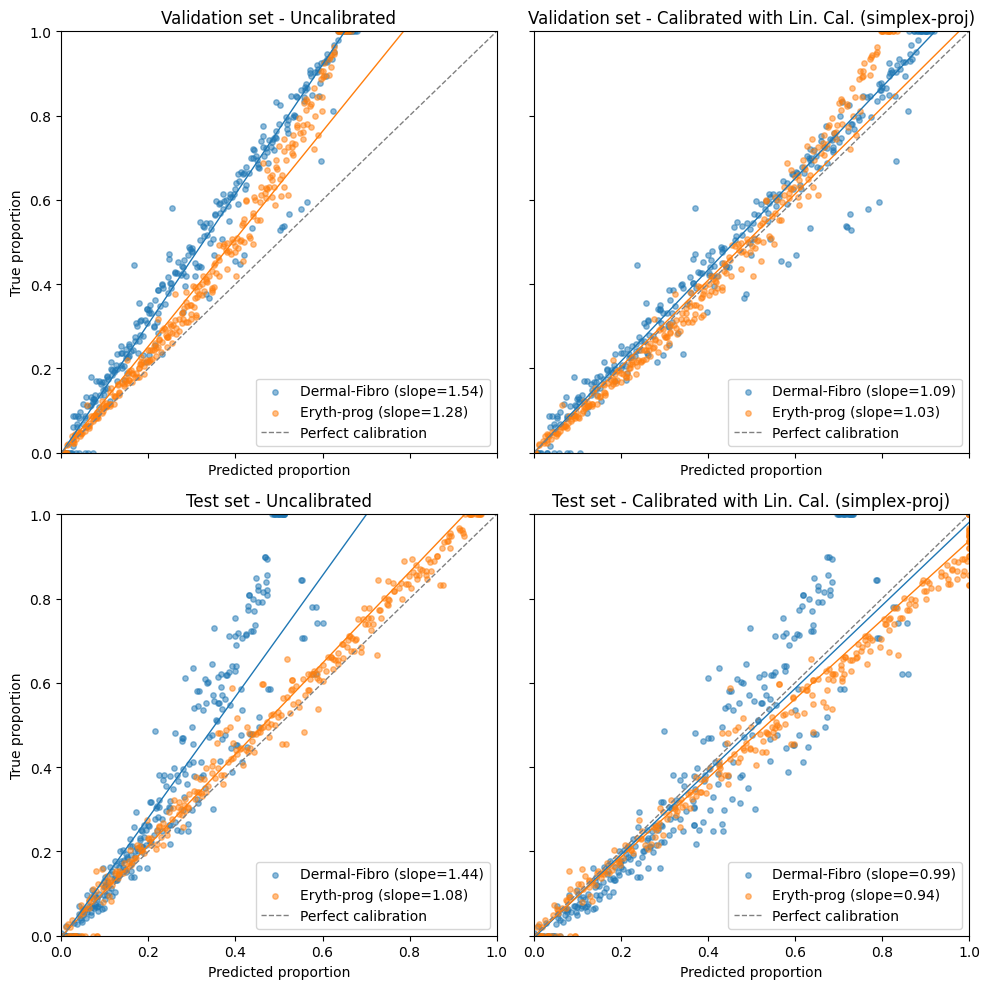

In [56]:
N_SUBSAMPLE = 300

datasets = ["val", "test"]
cols = ["uncalibrated", "calibrated"]
cells = ["max_slope", "min_slope"]
colors = {"max_slope": "C0", "min_slope": "C1"}

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
for i, ds in enumerate(datasets):
    # precompute subsample indices per cell using the uncalibrated predictions so calibrated and uncalibrated use the same indices
    idx_by_cell = {}
    for cell_key in cells:
        uncal_pred = results[cell_key][ds]["uncalibrated"]
        idx_by_cell[cell_key] = subsample_uniform_across_range(
            uncal_pred, N_SUBSAMPLE, random_state=42
        )
    for j, calib in enumerate(cols):
        ax = axes[i, j]
        for k, cell_key in enumerate(cells):
            pred = results[cell_key][ds][calib]
            cell_idx = cell_idx_dict[cell_key]
            true = (
                valid_target_prop[:, cell_idx]
                if ds == "val"
                else test_target_prop[:, cell_idx]
            )
            # use the same indices for calibrated and uncalibrated
            idx = idx_by_cell[cell_key]
            x = pred[idx]
            y = true[idx]
            name = ctype_names_list[cell_idx]
            # regression is computed with all points
            slope, intercept = slopes_intercepts_dict[cell_key][ds][calib]
            # plot
            ax.scatter(
                x,
                y,
                s=15,
                alpha=0.5,
                color=colors[cell_key],
                label=f"{name} (slope={slope:.2f})",
            )
            ax.plot(
                REGRESSION_X,
                regression_y[cell_key][ds][calib],
                color=colors[cell_key],
                lw=1,
            )
        ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Perfect calibration")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Predicted proportion")
        if j == 0:
            ax.set_ylabel("True proportion")
        title_ds = "Validation" if ds == "val" else "Test"
        title_calib = (
            "Uncalibrated"
            if calib == "uncalibrated"
            else "Calibrated with Lin. Cal. (simplex-proj)"
        )
        ax.set_title(f"{title_ds} set - {title_calib}")
        # if i == 0 and j == 1:
        ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../output/neurips_figures/linear_calibration_illustration.pdf")
plt.show()